Name: Rahul Gupta

Register Number: 2547242

Class: 4 MCA B

Subject: ML

Date: 08-06-26

---

#### Overview

Perform Simple Linear Regression analysis to determine if:

1. CIA Percentage can predict GPA

2. Attendance % can predict GPA

Implement regression using:

- Scikit-learn's LinearRegression

- Manual OLS formulas

### Part A: Data Collection and Preprocessing

Load libraries

In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("All libraries imported successfully!")

All libraries imported successfully!


Load the dataset using Pandas and display the first 5 rows

In [4]:
# Load the Dataset
df = pd.read_csv("../datasets/StudentAwarenessSurvey.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


Check dataset dimensions

In [5]:
# Check dataset dimensions
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 50 rows and 15 columns


Identify missing values

In [8]:
# Identify missing values

print("Missing values in each column:")
print(df.isnull().sum())

print("\nPercentage of missing values:")
print((df.isnull().sum() / len(df)) * 100)

Missing values in each column:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are 

Remove or handle null values

In [13]:
# Handle missing values

# relevant columns
cia_col = 'Your CIA % of last semester'
gpa_col = 'Your GPA of last semester'
attendance_col = 'Your maximum attendance % till last semester'

# remove rows with any missing values in the 3 key columns we need
df_clean = df.dropna(subset=[cia_col, gpa_col, attendance_col])

print(f"Total rows: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Total rows: 50
Rows after cleaning: 50
Rows removed: 0


Convert required columns into numerical datatype

In [15]:
# Convert columns to numeric datatype - cia %, gpa, attendance %

def convert_to_numeric(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    # Convert string values
    value_str = str(value).strip()
    # Remove % symbol if present
    if '%' in value_str:
        value_str = value_str.replace('%', '')
    # Handle values with spaces 
    value_str = value_str.strip()
    try:
        return float(value_str)
    except:
        return np.nan

# apply conversion to cia column
df_clean[cia_col] = df_clean[cia_col].apply(convert_to_numeric)

# apply conversion to gpa column
df_clean[gpa_col] = df_clean[gpa_col].apply(convert_to_numeric)

# apply conversion to attendance column
df_clean[attendance_col] = df_clean[attendance_col].apply(convert_to_numeric)

print(f"After cleaning and conversion, final dataset size: {len(df_clean)} rows")

After cleaning and conversion, final dataset size: 50 rows


Remove duplicate records if present

In [16]:
# remove duplicate records

duplicates = df_clean.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

df_clean = df_clean.drop_duplicates()
print(f"Rows after removing duplicates: {len(df_clean)}")

Number of duplicate rows: 0
Rows after removing duplicates: 50


Generate Statistical Summary

In [20]:
# Generate Statistical Summary

print(f"CIA Column: \n{df_clean[cia_col].describe()}")
print(f"\nGPA Column: \n{df_clean[gpa_col].describe()}")
print(f"\nAttendance Column: \n{df_clean[attendance_col].describe()}")

CIA Column: 
count    50.000000
mean     71.508600
std      11.247756
min       7.000000
25%      69.195000
50%      71.445000
75%      76.750000
max      91.000000
Name: Your CIA % of last semester, dtype: float64

GPA Column: 
count    50.000000
mean      3.497000
std       0.690865
min       2.740000
25%       3.305000
50%       3.400000
75%       3.600000
max       8.000000
Name: Your GPA of last semester, dtype: float64

Attendance Column: 
count     50.000000
mean      93.824800
std        3.852926
min       85.000000
25%       92.000000
50%       95.000000
75%       96.000000
max      100.000000
Name: Your maximum attendance % till last semester, dtype: float64


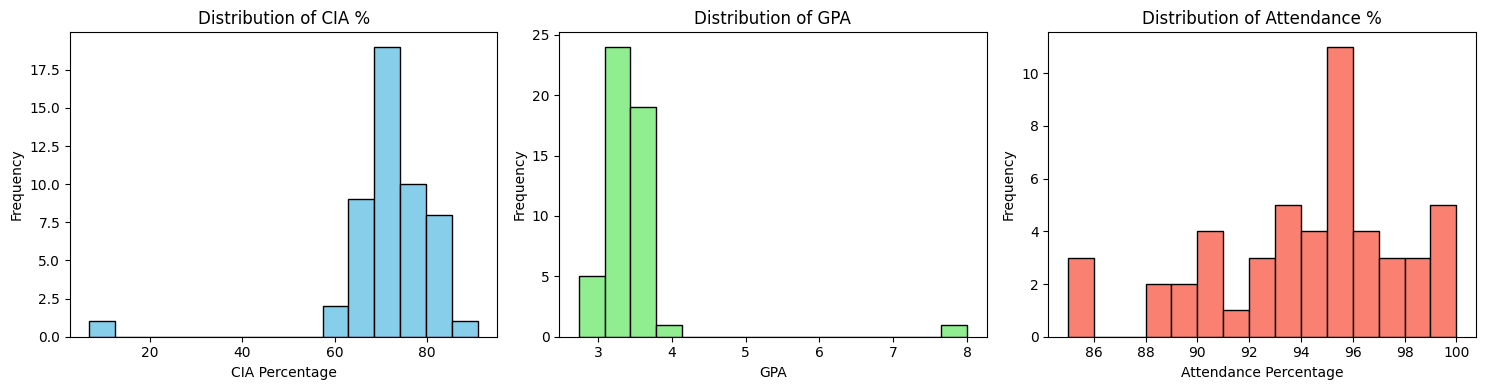

In [21]:
# Visualize data distribution

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# CIA distribution
axes[0].hist(df_clean[cia_col], bins=15, color='skyblue', edgecolor='black')
axes[0].set_xlabel('CIA Percentage')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of CIA %')

# GPA distribution
axes[1].hist(df_clean[gpa_col], bins=15, color='lightgreen', edgecolor='black')
axes[1].set_xlabel('GPA')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of GPA')

# Attendance distribution
axes[2].hist(df_clean[attendance_col], bins=15, color='salmon', edgecolor='black')
axes[2].set_xlabel('Attendance Percentage')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Attendance %')

plt.tight_layout()
plt.show()

Regression Experiments

In [22]:
# Select independent and dependent variables

# for experiment 1: cia % (x) and gpa (y)
X_cia = df_clean[cia_col].values.reshape(-1, 1)
y_gpa = df_clean[gpa_col].values

# for experiment 2: attendance % (x) and gpa (y)
X_att = df_clean[attendance_col].values.reshape(-1, 1)

print(f"Experiment 1 - CIA Shape: {X_cia.shape}, GPA Shape: {y_gpa.shape}")
print(f"Experiment 2 - Attendance Shape: {X_att.shape}, GPA Shape: {y_gpa.shape}")

print("\nSample Data:")
print(f"CIA: {X_cia[:5].flatten()}")
print(f"GPA: {y_gpa[:5]}")
print(f"Attendance: {X_att[:5].flatten()}")

Experiment 1 - CIA Shape: (50, 1), GPA Shape: (50,)
Experiment 2 - Attendance Shape: (50, 1), GPA Shape: (50,)

Sample Data:
CIA: [69. 75. 82. 91. 70.]
GPA: [3.4  3.69 3.41 3.6  3.54]
Attendance: [98. 95. 95. 92. 93.]


---

### Part B: Simple Linear Regression using Scikit-learn

In [23]:
# split for experiment 1 (cia -> gpa)
X_cia_train, X_cia_test, y_train, y_test = train_test_split(
    X_cia, y_gpa, test_size=0.2, random_state=42
)

# split for experiment 2 (attendance -> gpa)
X_att_train, X_att_test, y_att_train, y_att_test = train_test_split(
    X_att, y_gpa, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_cia_train)}")
print(f"Testing set size: {len(X_cia_test)}")

Training set size: 40
Testing set size: 10


In [24]:
# Create and train the model for CIA vs GPA
model_cia = LinearRegression()
model_cia.fit(X_cia_train, y_train)

# Get slope and intercept
slope_cia = model_cia.coef_[0]
intercept_cia = model_cia.intercept_

print("EXPERIMENT 1: CIA% -> GPA")
print(f"Slope (Coefficient): {slope_cia:.4f}")
print(f"Intercept: {intercept_cia:.4f}")
print(f"\nRegression Equation: GPA = {slope_cia:.4f} * (CIA%) + {intercept_cia:.4f}")

# Make predictions
y_pred_cia = model_cia.predict(X_cia_test)

# Calculate metrics
mse_cia = mean_squared_error(y_test, y_pred_cia)
r2_cia = r2_score(y_test, y_pred_cia)

print(f"\nMean Squared Error: {mse_cia:.4f}")
print(f"R-squared Score: {r2_cia:.4f}")

EXPERIMENT 1: CIA% -> GPA
Slope (Coefficient): 0.0128
Intercept: 2.4656

Regression Equation: GPA = 0.0128 * (CIA%) + 2.4656

Mean Squared Error: 3.0171
R-squared Score: -0.5500


In [25]:
# Create and train the model for Attendance vs GPA
model_att = LinearRegression()
model_att.fit(X_att_train, y_att_train)

# Get slope and intercept
slope_att = model_att.coef_[0]
intercept_att = model_att.intercept_

print("EXPERIMENT 2: Attendance% -> GPA")
print(f"Slope (Coefficient): {slope_att:.4f}")
print(f"Intercept: {intercept_att:.4f}")
print(f"\nRegression Equation: GPA = {slope_att:.4f} * (Attendance%) + {intercept_att:.4f}")

# Make predictions
y_pred_att = model_att.predict(X_att_test)

# Calculate metrics
mse_att = mean_squared_error(y_att_test, y_pred_att)
r2_att = r2_score(y_att_test, y_pred_att)

print(f"\nMean Squared Error: {mse_att:.4f}")
print(f"R-squared Score: {r2_att:.4f}")

EXPERIMENT 2: Attendance% -> GPA
Slope (Coefficient): 0.0158
Intercept: 1.9083

Regression Equation: GPA = 0.0158 * (Attendance%) + 1.9083

Mean Squared Error: 2.3086
R-squared Score: -0.1860


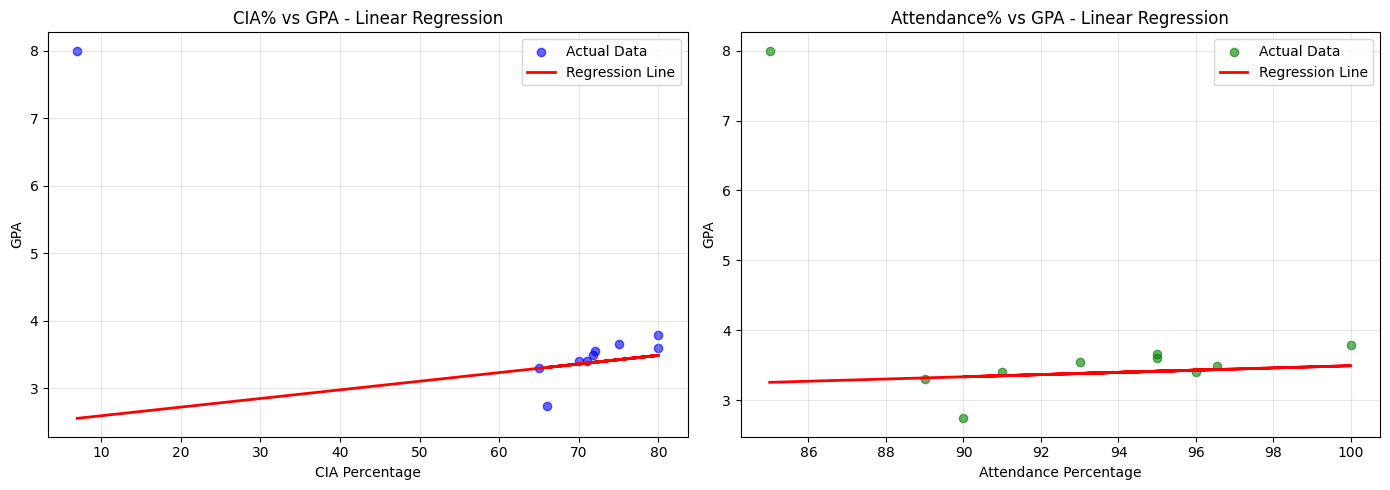

In [26]:
# Plot for Experiment 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Experiment 1 Plot
axes[0].scatter(X_cia_test, y_test, color='blue', alpha=0.6, label='Actual Data')
axes[0].plot(X_cia_test, y_pred_cia, color='red', linewidth=2, label='Regression Line')
axes[0].set_xlabel('CIA Percentage')
axes[0].set_ylabel('GPA')
axes[0].set_title('CIA% vs GPA - Linear Regression')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Experiment 2 Plot
axes[1].scatter(X_att_test, y_att_test, color='green', alpha=0.6, label='Actual Data')
axes[1].plot(X_att_test, y_pred_att, color='red', linewidth=2, label='Regression Line')
axes[1].set_xlabel('Attendance Percentage')
axes[1].set_ylabel('GPA')
axes[1].set_title('Attendance% vs GPA - Linear Regression')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

### Manual Computation using Ordinary Least Squares (OLS)

In [27]:
# Create helper functions for OLS Calculation

def calculate_slope_intercept_ols(x, y):
    # Calculate means
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # Calculate numerator and denominator for slope
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)
    
    # Calculate slope
    slope = numerator / denominator
    
    # Calculate intercept
    intercept = y_mean - slope * x_mean
    
    return slope, intercept

def predict_ols(x, slope, intercept):
    return slope * x + intercept

In [29]:
# Manual OLS caclulation for Experiment 1

# Use all data for manual calculation (or you can use training data only)
print("MANUAL OLS CALCULATION - EXPERIMENT 1: CIA% -> GPA")

# Get the x and y values (using all data)
x_cia_all = X_cia.flatten()
y_gpa_all = y_gpa

# Calculate slope and intercept manually
slope_cia_manual, intercept_cia_manual = calculate_slope_intercept_ols(x_cia_all, y_gpa_all)

print(f"Manual Slope (m): {slope_cia_manual:.6f}")
print(f"Manual Intercept (b): {intercept_cia_manual:.6f}")
print(f"\nManual Regression Equation: GPA = {slope_cia_manual:.4f} * (CIA%) + {intercept_cia_manual:.4f}")

# Show step-by-step calculation
x_mean = np.mean(x_cia_all)
y_mean = np.mean(y_gpa_all)
print(f"\nStep-by-step:")
print(f"x̄ (mean CIA) = {x_mean:.4f}")
print(f"ȳ (mean GPA) = {y_mean:.4f}")
print(f"Σ((x_i - x̄)(y_i - ȳ)) = {np.sum((x_cia_all - x_mean) * (y_gpa_all - y_mean)):.6f}")
print(f"Σ((x_i - x̄)²) = {np.sum((x_cia_all - x_mean) ** 2):.6f}")

MANUAL OLS CALCULATION - EXPERIMENT 1: CIA% -> GPA
Manual Slope (m): -0.042670
Manual Intercept (b): 6.548303

Manual Regression Equation: GPA = -0.0427 * (CIA%) + 6.5483

Step-by-step:
x̄ (mean CIA) = 71.5086
ȳ (mean GPA) = 3.4970
Σ((x_i - x̄)(y_i - ȳ)) = -264.517810
Σ((x_i - x̄)²) = 6199.088802


In [30]:
# Manual OLS Calculation for Experiment 2

print("MANUAL OLS CALCULATION - EXPERIMENT 2: Attendance% -> GPA")

# Get the x and y values for attendance
x_att_all = X_att.flatten()

# Calculate slope and intercept manually
slope_att_manual, intercept_att_manual = calculate_slope_intercept_ols(x_att_all, y_gpa_all)

print(f"Manual Slope (m): {slope_att_manual:.6f}")
print(f"Manual Intercept (b): {intercept_att_manual:.6f}")
print(f"\nManual Regression Equation: GPA = {slope_att_manual:.4f} * (Attendance%) + {intercept_att_manual:.4f}")

# Show step-by-step calculation
x_mean = np.mean(x_att_all)
y_mean = np.mean(y_gpa_all)
print(f"\nStep-by-step:")
print(f"x̄ (mean Attendance) = {x_mean:.4f}")
print(f"ȳ (mean GPA) = {y_mean:.4f}")
print(f"Σ((x_i - x̄)(y_i - ȳ)) = {np.sum((x_att_all - x_mean) * (y_gpa_all - y_mean)):.6f}")
print(f"Σ((x_i - x̄)²) = {np.sum((x_att_all - x_mean) ** 2):.6f}")

MANUAL OLS CALCULATION - EXPERIMENT 2: Attendance% -> GPA
Manual Slope (m): -0.035527
Manual Intercept (b): 6.830326

Manual Regression Equation: GPA = -0.0355 * (Attendance%) + 6.8303

Step-by-step:
x̄ (mean Attendance) = 93.8248
ȳ (mean GPA) = 3.4970
Σ((x_i - x̄)(y_i - ȳ)) = -25.842680
Σ((x_i - x̄)²) = 727.406848


---

Compare Scikit-learn vs Manual OLS results

In [36]:
print("COMPARISON: Scikit-learn vs Manual OLS")

print("\n--- EXPERIMENT 1 (CIA% -> GPA) ---")
print(f"{'Method':<20} {'Slope':<12} {'Intercept':<12}")
print(f"{'Scikit-learn':<20} {slope_cia:.6f}   {intercept_cia:.6f}")
print(f"{'Manual OLS':<20} {slope_cia_manual:.6f}   {intercept_cia_manual:.6f}")
print(f"{'Difference':<20} {abs(slope_cia - slope_cia_manual):.10f}   {abs(intercept_cia - intercept_cia_manual):.10f}")

print("\n--- EXPERIMENT 2 (Attendance% -> GPA) ---")
print(f"{'Method':<20} {'Slope':<12} {'Intercept':<12}")
print(f"{'Scikit-learn':<20} {slope_att:.6f}   {intercept_att:.6f}")
print(f"{'Manual OLS':<20} {slope_att_manual:.6f}   {intercept_att_manual:.6f}")
print(f"{'Difference':<20} {abs(slope_att - slope_att_manual):.10f}   {abs(intercept_att - intercept_att_manual):.10f}")

COMPARISON: Scikit-learn vs Manual OLS

--- EXPERIMENT 1 (CIA% -> GPA) ---
Method               Slope        Intercept   
Scikit-learn         0.012783   2.465581
Manual OLS           -0.042670   6.548303
Difference           0.0554535786   4.0827215463

--- EXPERIMENT 2 (Attendance% -> GPA) ---
Method               Slope        Intercept   
Scikit-learn         0.015845   1.908332
Manual OLS           -0.035527   6.830326
Difference           0.0513717140   4.9219940405


In [35]:
# Compare predictions from both methods

# Make predictions using manual OLS for test data
y_pred_cia_manual = predict_ols(X_cia_test.flatten(), slope_cia_manual, intercept_cia_manual)
y_pred_att_manual = predict_ols(X_att_test.flatten(), slope_att_manual, intercept_att_manual)

# Compare predictions
print("PREDICTION COMPARISON - First 10 test samples")

print("\n--- EXPERIMENT 1 (CIA% -> GPA) ---")
print(f"{'CIA%':<8} {'Actual GPA':<12} {'Sklearn Pred':<12} {'Manual Pred':<12} {'Difference':<12}")
for i in range(min(10, len(X_cia_test))):
    diff = abs(y_pred_cia[i] - y_pred_cia_manual[i])
    print(f"{X_cia_test[i][0]:<8.2f} {y_test[i]:<12.3f} {y_pred_cia[i]:<12.4f} {y_pred_cia_manual[i]:<12.4f} {diff:<12.10f}")

print("\n--- EXPERIMENT 2 (Attendance% -> GPA) ---")
print(f"{'Att%':<8} {'Actual GPA':<12} {'Sklearn Pred':<12} {'Manual Pred':<12} {'Difference':<12}")
for i in range(min(10, len(X_att_test))):
    diff = abs(y_pred_att[i] - y_pred_att_manual[i])
    print(f"{X_att_test[i][0]:<8.2f} {y_att_test[i]:<12.3f} {y_pred_att[i]:<12.4f} {y_pred_att_manual[i]:<12.4f} {diff:<12.10f}")

PREDICTION COMPARISON - First 10 test samples

--- EXPERIMENT 1 (CIA% -> GPA) ---
CIA%     Actual GPA   Sklearn Pred Manual Pred  Difference  
7.00     8.000        2.5551       6.2496       3.6945464957
65.00    3.300        3.2965       3.7747       0.4782389341
80.00    3.790        3.4882       3.1347       0.3535647457
75.00    3.660        3.4243       3.3480       0.0762968524
71.00    3.400        3.3732       3.5187       0.1455174622
66.00    2.740        3.3093       3.7321       0.4227853554
70.00    3.400        3.3604       3.5614       0.2009710408
72.00    3.550        3.3860       3.4760       0.0900638835
80.00    3.600        3.4882       3.1347       0.3535647457
71.78    3.490        3.3832       3.4854       0.1022636708

--- EXPERIMENT 2 (Attendance% -> GPA) ---
Att%     Actual GPA   Sklearn Pred Manual Pred  Difference  
85.00    8.000        3.2551       3.8105       0.5553983522
89.00    3.300        3.3185       3.6684       0.3499114963
100.00   3.790       

In [38]:
# Statistical comparison metrics

# Calculate metrics for manual predictions
mse_cia_manual = mean_squared_error(y_test, y_pred_cia_manual)
r2_cia_manual = r2_score(y_test, y_pred_cia_manual)

mse_att_manual = mean_squared_error(y_att_test, y_pred_att_manual)
r2_att_manual = r2_score(y_att_test, y_pred_att_manual)

print("METRICS COMPARISON")

print("\n--- EXPERIMENT 1 (CIA% -> GPA) ---")
print(f"{'Metric':<15} {'Scikit-learn':<15} {'Manual OLS':<15}")
print(f"{'MSE':<15} {mse_cia:<15.6f} {mse_cia_manual:<15.6f}")
print(f"{'R² Score':<15} {r2_cia:<15.6f} {r2_cia_manual:<15.6f}")

print("\n--- EXPERIMENT 2 (Attendance% -> GPA) ---")
print(f"{'Metric':<15} {'Scikit-learn':<15} {'Manual OLS':<15}")
print(f"{'MSE':<15} {mse_att:<15.6f} {mse_att_manual:<15.6f}")
print(f"{'R² Score':<15} {r2_att:<15.6f} {r2_att_manual:<15.6f}")

METRICS COMPARISON

--- EXPERIMENT 1 (CIA% -> GPA) ---
Metric          Scikit-learn    Manual OLS     
MSE             3.017112        0.506235       
R² Score        -0.549987       0.739931       

--- EXPERIMENT 2 (Attendance% -> GPA) ---
Metric          Scikit-learn    Manual OLS     
MSE             2.308560        1.885803       
R² Score        -0.185981       0.031203       


---

Save model parameters using Pickle

In [39]:
# Create dictionary with all model parameters
model_parameters = {
    'experiment_1': {
        'independent_variable': 'CIA Percentage',
        'dependent_variable': 'GPA',
        'slope': slope_cia,
        'intercept': intercept_cia,
        'r2_score': r2_cia,
        'mse': mse_cia
    },
    'experiment_2': {
        'independent_variable': 'Attendance Percentage',
        'dependent_variable': 'GPA',
        'slope': slope_att,
        'intercept': intercept_att,
        'r2_score': r2_att,
        'mse': mse_att
    }
}

# Save parameters to pickle file
file_loc = '../models/linear_regression_weights.pkl'
with open(file_loc, 'wb') as file:
    pickle.dump(model_parameters, file)

print(f"Parameters saved successfully to {file_loc}")
print("\nSaved parameters:")
print(model_parameters)

Parameters saved successfully to ../models/linear_regression_weights.pkl

Saved parameters:
{'experiment_1': {'independent_variable': 'CIA Percentage', 'dependent_variable': 'GPA', 'slope': 0.01278314458206303, 'intercept': 2.4655814552535955, 'r2_score': -0.5499865790161718, 'mse': 3.0171124255047177}, 'experiment_2': {'independent_variable': 'Attendance Percentage', 'dependent_variable': 'GPA', 'slope': 0.015844580750996734, 'intercept': 1.9083321292431652, 'r2_score': -0.18598056401716012, 'mse': 2.3085597930625266}}


Load pickle file and use for prediction

In [41]:
# Load the saved parameters
with open(file_loc, 'rb') as file:
    loaded_params = pickle.load(file)

print("Parameters loaded successfully!")
print("\nLoaded parameters:")
print(loaded_params)

# Use loaded parameters for prediction
print("PREDICTIONS USING LOADED PARAMETERS")

# Example predictions
example_cia = np.array([[75], [80], [85], [90]])
example_att = np.array([[90], [92], [95], [98]])

# Get slopes and intercepts from loaded params
slope1 = loaded_params['experiment_1']['slope']
intercept1 = loaded_params['experiment_1']['intercept']
slope2 = loaded_params['experiment_2']['slope']
intercept2 = loaded_params['experiment_2']['intercept']

# Make predictions
pred_gpa_cia = slope1 * example_cia + intercept1
pred_gpa_att = slope2 * example_att + intercept2

print("\nPredictions using CIA%:")
for cia, gpa in zip(example_cia.flatten(), pred_gpa_cia.flatten()):
    print(f"CIA: {cia:.0f}% -> Predicted GPA: {gpa:.3f}")

print("\nPredictions using Attendance%:")
for att, gpa in zip(example_att.flatten(), pred_gpa_att.flatten()):
    print(f"Attendance: {att:.0f}% -> Predicted GPA: {gpa:.3f}")

Parameters loaded successfully!

Loaded parameters:
{'experiment_1': {'independent_variable': 'CIA Percentage', 'dependent_variable': 'GPA', 'slope': 0.01278314458206303, 'intercept': 2.4655814552535955, 'r2_score': -0.5499865790161718, 'mse': 3.0171124255047177}, 'experiment_2': {'independent_variable': 'Attendance Percentage', 'dependent_variable': 'GPA', 'slope': 0.015844580750996734, 'intercept': 1.9083321292431652, 'r2_score': -0.18598056401716012, 'mse': 2.3085597930625266}}
PREDICTIONS USING LOADED PARAMETERS

Predictions using CIA%:
CIA: 75% -> Predicted GPA: 3.424
CIA: 80% -> Predicted GPA: 3.488
CIA: 85% -> Predicted GPA: 3.552
CIA: 90% -> Predicted GPA: 3.616

Predictions using Attendance%:
Attendance: 90% -> Predicted GPA: 3.334
Attendance: 92% -> Predicted GPA: 3.366
Attendance: 95% -> Predicted GPA: 3.414
Attendance: 98% -> Predicted GPA: 3.461
